# Kuramoto Benchmark

This notebook imports saved controlled noisy Kuramoto runs from `results/kuramoto`. It is analysis-only and does not launch training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    flow_dataframe,
    load_env_and_policy,
    load_runs,
    objective_table,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)
from mfc.visualization.io import run_label

ENV = 'kuramoto'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 25 saved runs from /home/adonis/Internship/mfc/results/kuramoto


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. The planned Kuramoto runs use particle population flow.

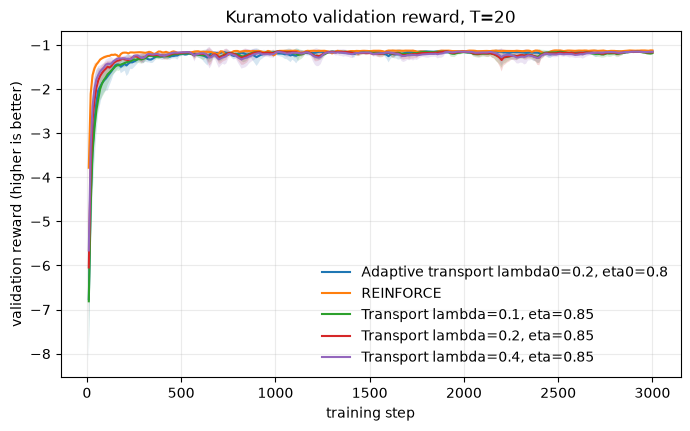

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py or scripts/parallel_train.py before executing the analysis cells.')
else:
    for horizon in sorted({run['metadata']['horizon'] for run in runs}):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        try:
            plot_validation_rewards(runs, env=ENV, horizon=horizon, flow='particle', ax=ax)
            ax.set_title(f'Kuramoto validation reward, T={horizon}')
            plt.show()
        except ValueError as exc:
            plt.close(fig)
            print(exc)

## Fourier Moment Flow

The learned population law is summarized by the first Fourier moments `C`, `S`, and the order parameter `R = sqrt(C^2 + S^2)`. The plots below use the best saved seed for each algorithm and perturbation setting.

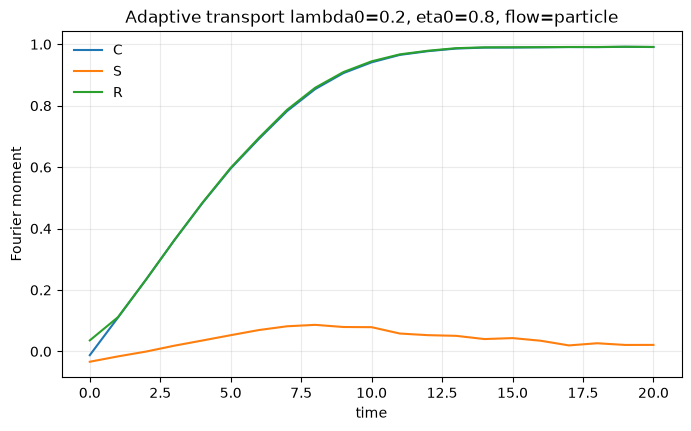

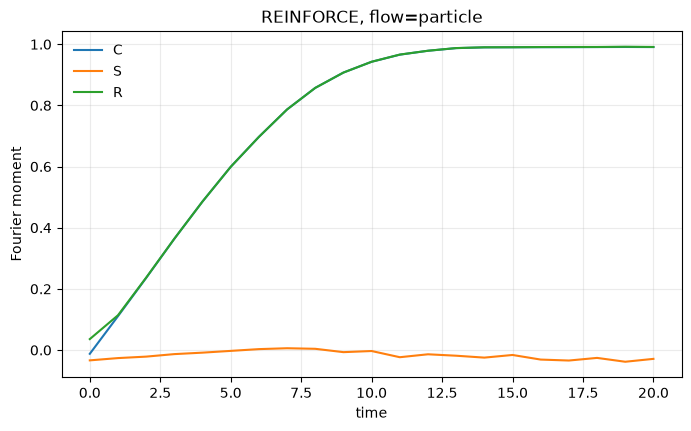

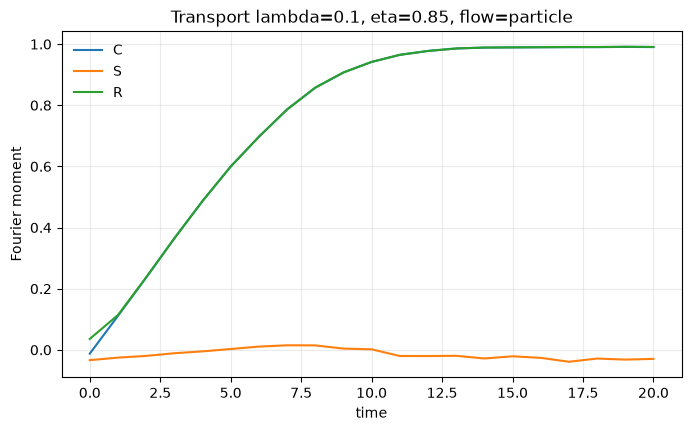

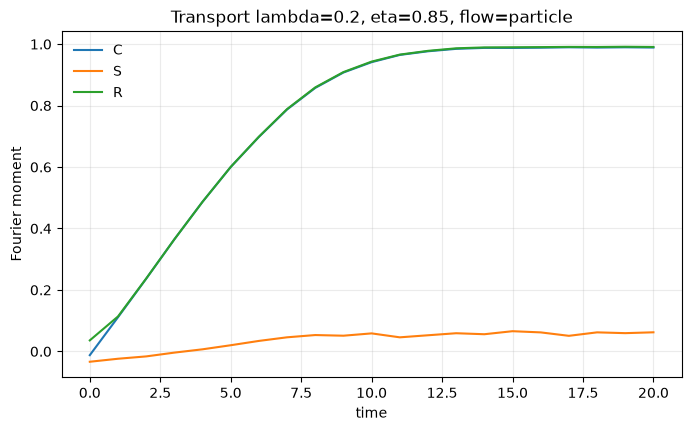

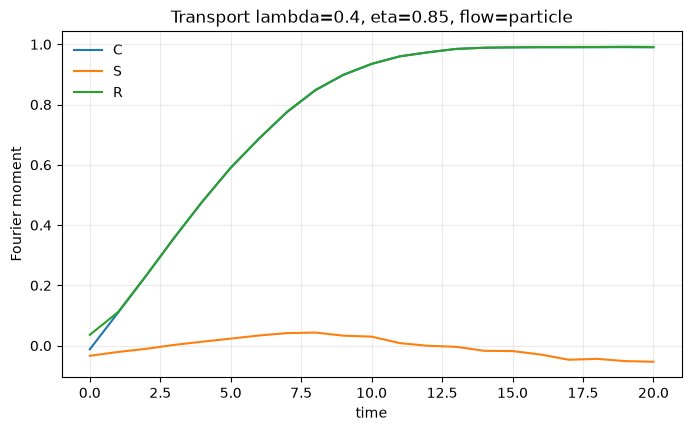

In [3]:
if not runs:
    print('No saved runs yet.')
else:
    for run in best_runs_by_label(runs):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        plot_state_flow(run, ax=ax)
        meta = run['metadata']
        label = run_label(meta)
        ax.set_title(f'{label}, flow={meta["flow"]}')
        plt.show()

## Order Parameter Table

Final and maximum order parameter reached by each selected policy. Larger values indicate stronger synchronization of the population.

In [4]:
rows = []
for run in best_runs_by_label(runs):
    meta = run['metadata']
    flow = flow_dataframe(run)
    if flow.empty:
        continue
    rows.append({
        'label': run_label(meta),
        'horizon': meta['horizon'],
        'flow': meta['flow'],
        'seed': meta['seed'],
        'final_R': flow['order_parameter'].iloc[-1],
        'max_R': flow['order_parameter'].max(),
        'final_C': flow['cos_moment'].iloc[-1],
        'final_S': flow['sin_moment'].iloc[-1],
    })
order_table = pd.DataFrame(rows)
display(order_table)

,label,horizon,flow,seed,final_R,max_R,final_C,final_S
0,"Adaptive transport lambda0=0.2, eta0=0.8",20,particle,1,0.991204,0.991902,0.990978,0.021153
1,REINFORCE,20,particle,3,0.991172,0.991828,0.990753,-0.028815
2,"Transport lambda=0.1, eta=0.85",20,particle,1,0.990764,0.991379,0.990324,-0.029508
3,"Transport lambda=0.2, eta=0.85",20,particle,1,0.990766,0.991445,0.988815,0.062148
4,"Transport lambda=0.4, eta=0.85",20,particle,2,0.991241,0.991892,0.989799,-0.053431


## Phase Cloud Rollout

A qualitative rollout for one saved policy. Points are particles on the unit circle at selected times; the red marker shows the mean direction and length of the order parameter.

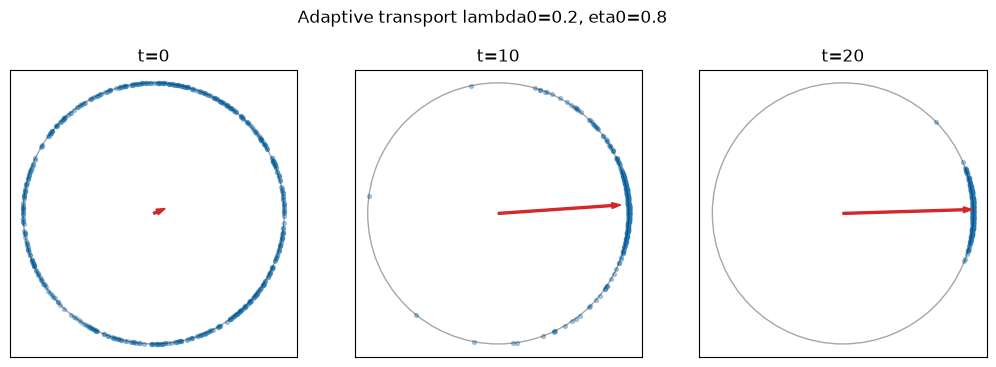

In [5]:
def rollout_phase_cloud(run, n_particles=512, seed=1234):
    env, policy = load_env_and_policy(run)
    generator = torch.Generator(device=env.device)
    generator.manual_seed(seed)
    states = env.sample_initial(n_particles, generator)
    snapshots = {0: states.detach().cpu()}
    horizon = run['metadata']['horizon']
    selected = {0, horizon // 2, horizon}

    with torch.no_grad():
        for t in range(horizon):
            law = env.empirical_law(states)
            actions = env.sample_action(policy, t, states, law, generator)
            states = env.sample(states, law, actions, generator, t=t)
            if t + 1 in selected:
                snapshots[t + 1] = states.detach().cpu()
    return snapshots

if not runs:
    print('No saved runs yet.')
else:
    run = best_runs_by_label(runs)[0]
    snapshots = rollout_phase_cloud(run)
    fig, axes = plt.subplots(1, len(snapshots), figsize=(4.2 * len(snapshots), 4.2), subplot_kw={'aspect': 'equal'})
    if len(snapshots) == 1:
        axes = [axes]
    for ax, (time, phases) in zip(axes, snapshots.items()):
        x = torch.cos(phases).numpy()
        y = torch.sin(phases).numpy()
        ax.scatter(x, y, s=8, alpha=0.35)
        c = x.mean()
        s = y.mean()
        ax.arrow(0, 0, c, s, width=0.015, color='tab:red', length_includes_head=True)
        circle = plt.Circle((0, 0), 1.0, fill=False, color='black', alpha=0.35)
        ax.add_artist(circle)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f't={time}')
    fig.suptitle(run_label(run['metadata']))
    plt.show()

## Objective and Runtime Tables

Final validation reward, estimated simulator budget, and wall-clock timing for each saved configuration.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,eta,seed,validation_reward,objective_convention
0,kuramoto,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,0.665519,0,-1.139815,reward
1,kuramoto,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,0.710989,1,-1.139209,reward
2,kuramoto,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,0.677404,2,-1.139221,reward
3,kuramoto,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,0.699458,3,-1.148910,reward
4,kuramoto,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,0.652007,4,-1.139977,reward
5,kuramoto,REINFORCE,particle,20,NaN,0,-1.124542,reward
6,kuramoto,REINFORCE,particle,20,NaN,1,-1.122981,reward
7,kuramoto,REINFORCE,particle,20,NaN,2,-1.125142,reward
8,kuramoto,REINFORCE,particle,20,NaN,3,-1.122083,reward
9,kuramoto,REINFORCE,particle,20,NaN,4,-1.123547,reward


,env,algorithm,perturbation,eta,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,kuramoto,adaptive_transport,0.2,NaN,20,particle,10.811253,1.081368,1797.507675,168.870036,20.028637,0.740901,1828.419227,168.499368,0.599169,0.609473,0.066762,28381.6,5
1,kuramoto,reinforce,NaN,NaN,20,particle,34.248115,0.098242,171.997427,0.597434,19.647044,0.110727,225.910149,0.691095,0.057332,0.075303,0.065490,18400.0,5
2,kuramoto,transport,0.1,0.85,20,particle,34.430153,0.426117,3011.477481,152.179987,20.877628,0.337936,3066.837536,151.836707,1.003826,1.022279,0.069592,28400.0,5
3,kuramoto,transport,0.2,0.85,20,particle,18.884764,13.760516,2891.782587,530.878995,20.648886,0.305991,2931.351065,522.079738,0.963928,0.977117,0.068830,28400.0,5
4,kuramoto,transport,0.4,0.85,20,particle,9.739950,0.378616,3103.844314,476.067353,20.856475,0.323039,3134.496324,475.947858,1.034615,1.044832,0.069522,28400.0,5
